# Visualization of Validation using the Library Bambi

In [ ]:
import arviz as az
import pandas as pd
from anthromass.anthro_module import *
az.style.use("arviz-darkgrid")

Making a model to visualize. Here we used the measurement "neckcircumference" as an example, insert the measurement you desire to visualize. 

In [7]:
formula ='0 + C(Gender) + Component + weightkg + stature'
model = make_model_formula('neckcircumference',formula)
model.build()
fitted = fit_model('neckcircumference',formula)

Initializing NUTS using adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, C(Gender), Component, weightkg, stature]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 23 seconds.


Table of summarized parameters.

In [8]:
def summary(fitted):
    return az.summary(fitted)

In [9]:
summary(fitted)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,14.089,0.146,13.821,14.364,0.001,0.002,10440.0,6168.0,1.0
C(Gender)[0],342.829,0.497,341.900,343.766,0.005,0.005,8702.0,6208.0,1.0
C(Gender)[1],392.018,0.350,391.323,392.637,0.004,0.004,7620.0,6045.0,1.0
Component[Army Reserve],0.585,1.104,-1.390,2.772,0.011,0.012,9908.0,6214.0,1.0
Component[Regular Army],-0.971,0.405,-1.748,-0.230,0.005,0.004,7660.0,6298.0,1.0
weightkg,1.614,0.017,1.583,1.648,0.000,0.000,9350.0,6011.0,1.0
stature,-0.077,0.003,-0.083,-0.070,0.000,0.000,8368.0,5724.0,1.0


Graph of the model.

In [10]:
def graph(model):
    return model.graph()

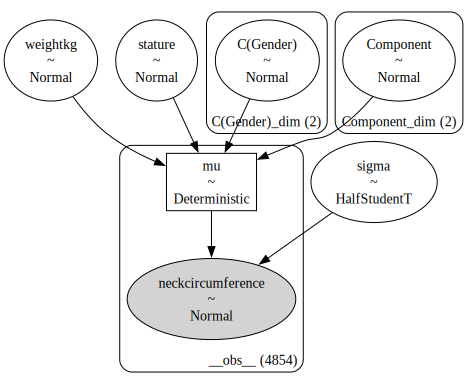

In [11]:
graph(model)

Plotting the prior predictive.

In [12]:
def plot_prior_predictive(model):
    prior_pred = model.prior_predictive(draws=1000)
    az.plot_ppc(prior_pred, group='prior')

Sampling: [C(Gender), Component, neckcircumference, sigma, stature, weightkg]


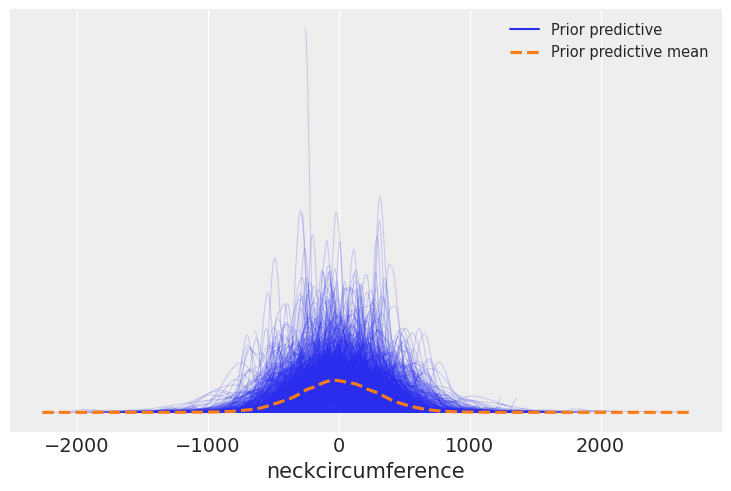

In [13]:
plot_prior_predictive(model)

Plotting the posterior predictive.

In [14]:
def plot_posterior_predictive(model, fitted):
    model.predict(fitted, kind='response')
    az.plot_ppc(fitted)

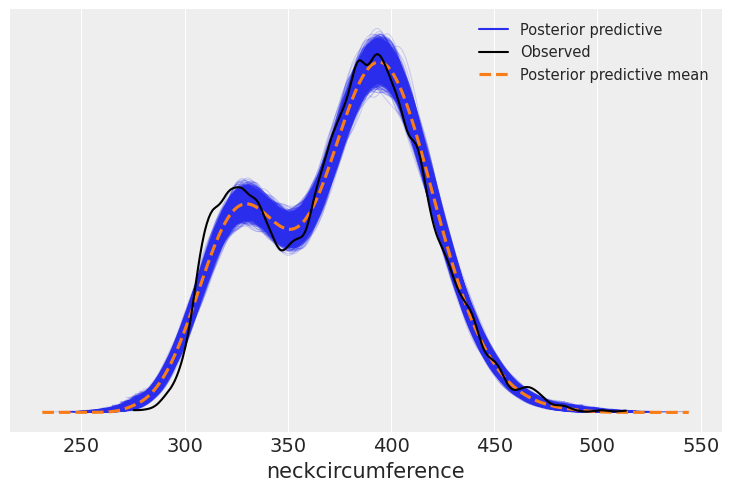

In [15]:
plot_posterior_predictive(model, fitted)

Forest plot.

In [16]:
def plot_forest(fitted, variables:list):
    az.plot_forest(fitted, var_names=variables)

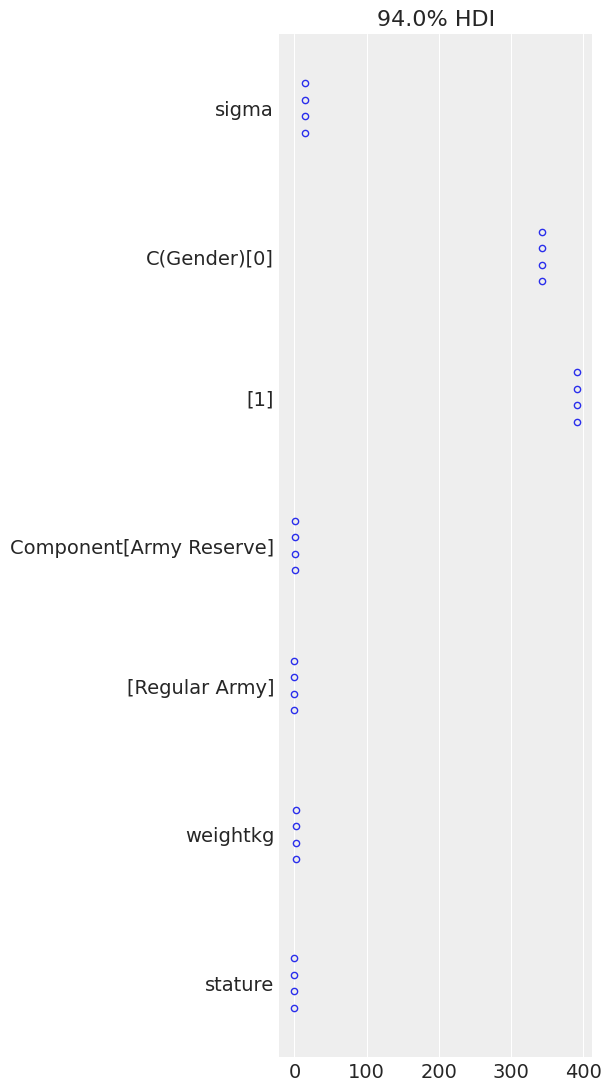

In [17]:
plot_forest(fitted, variables= ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

Plot the HDI of the priors.

In [18]:
def plot_hdi_priors(model):
    model.plot_priors()

Sampling: [C(Gender), Component, sigma, stature, weightkg]


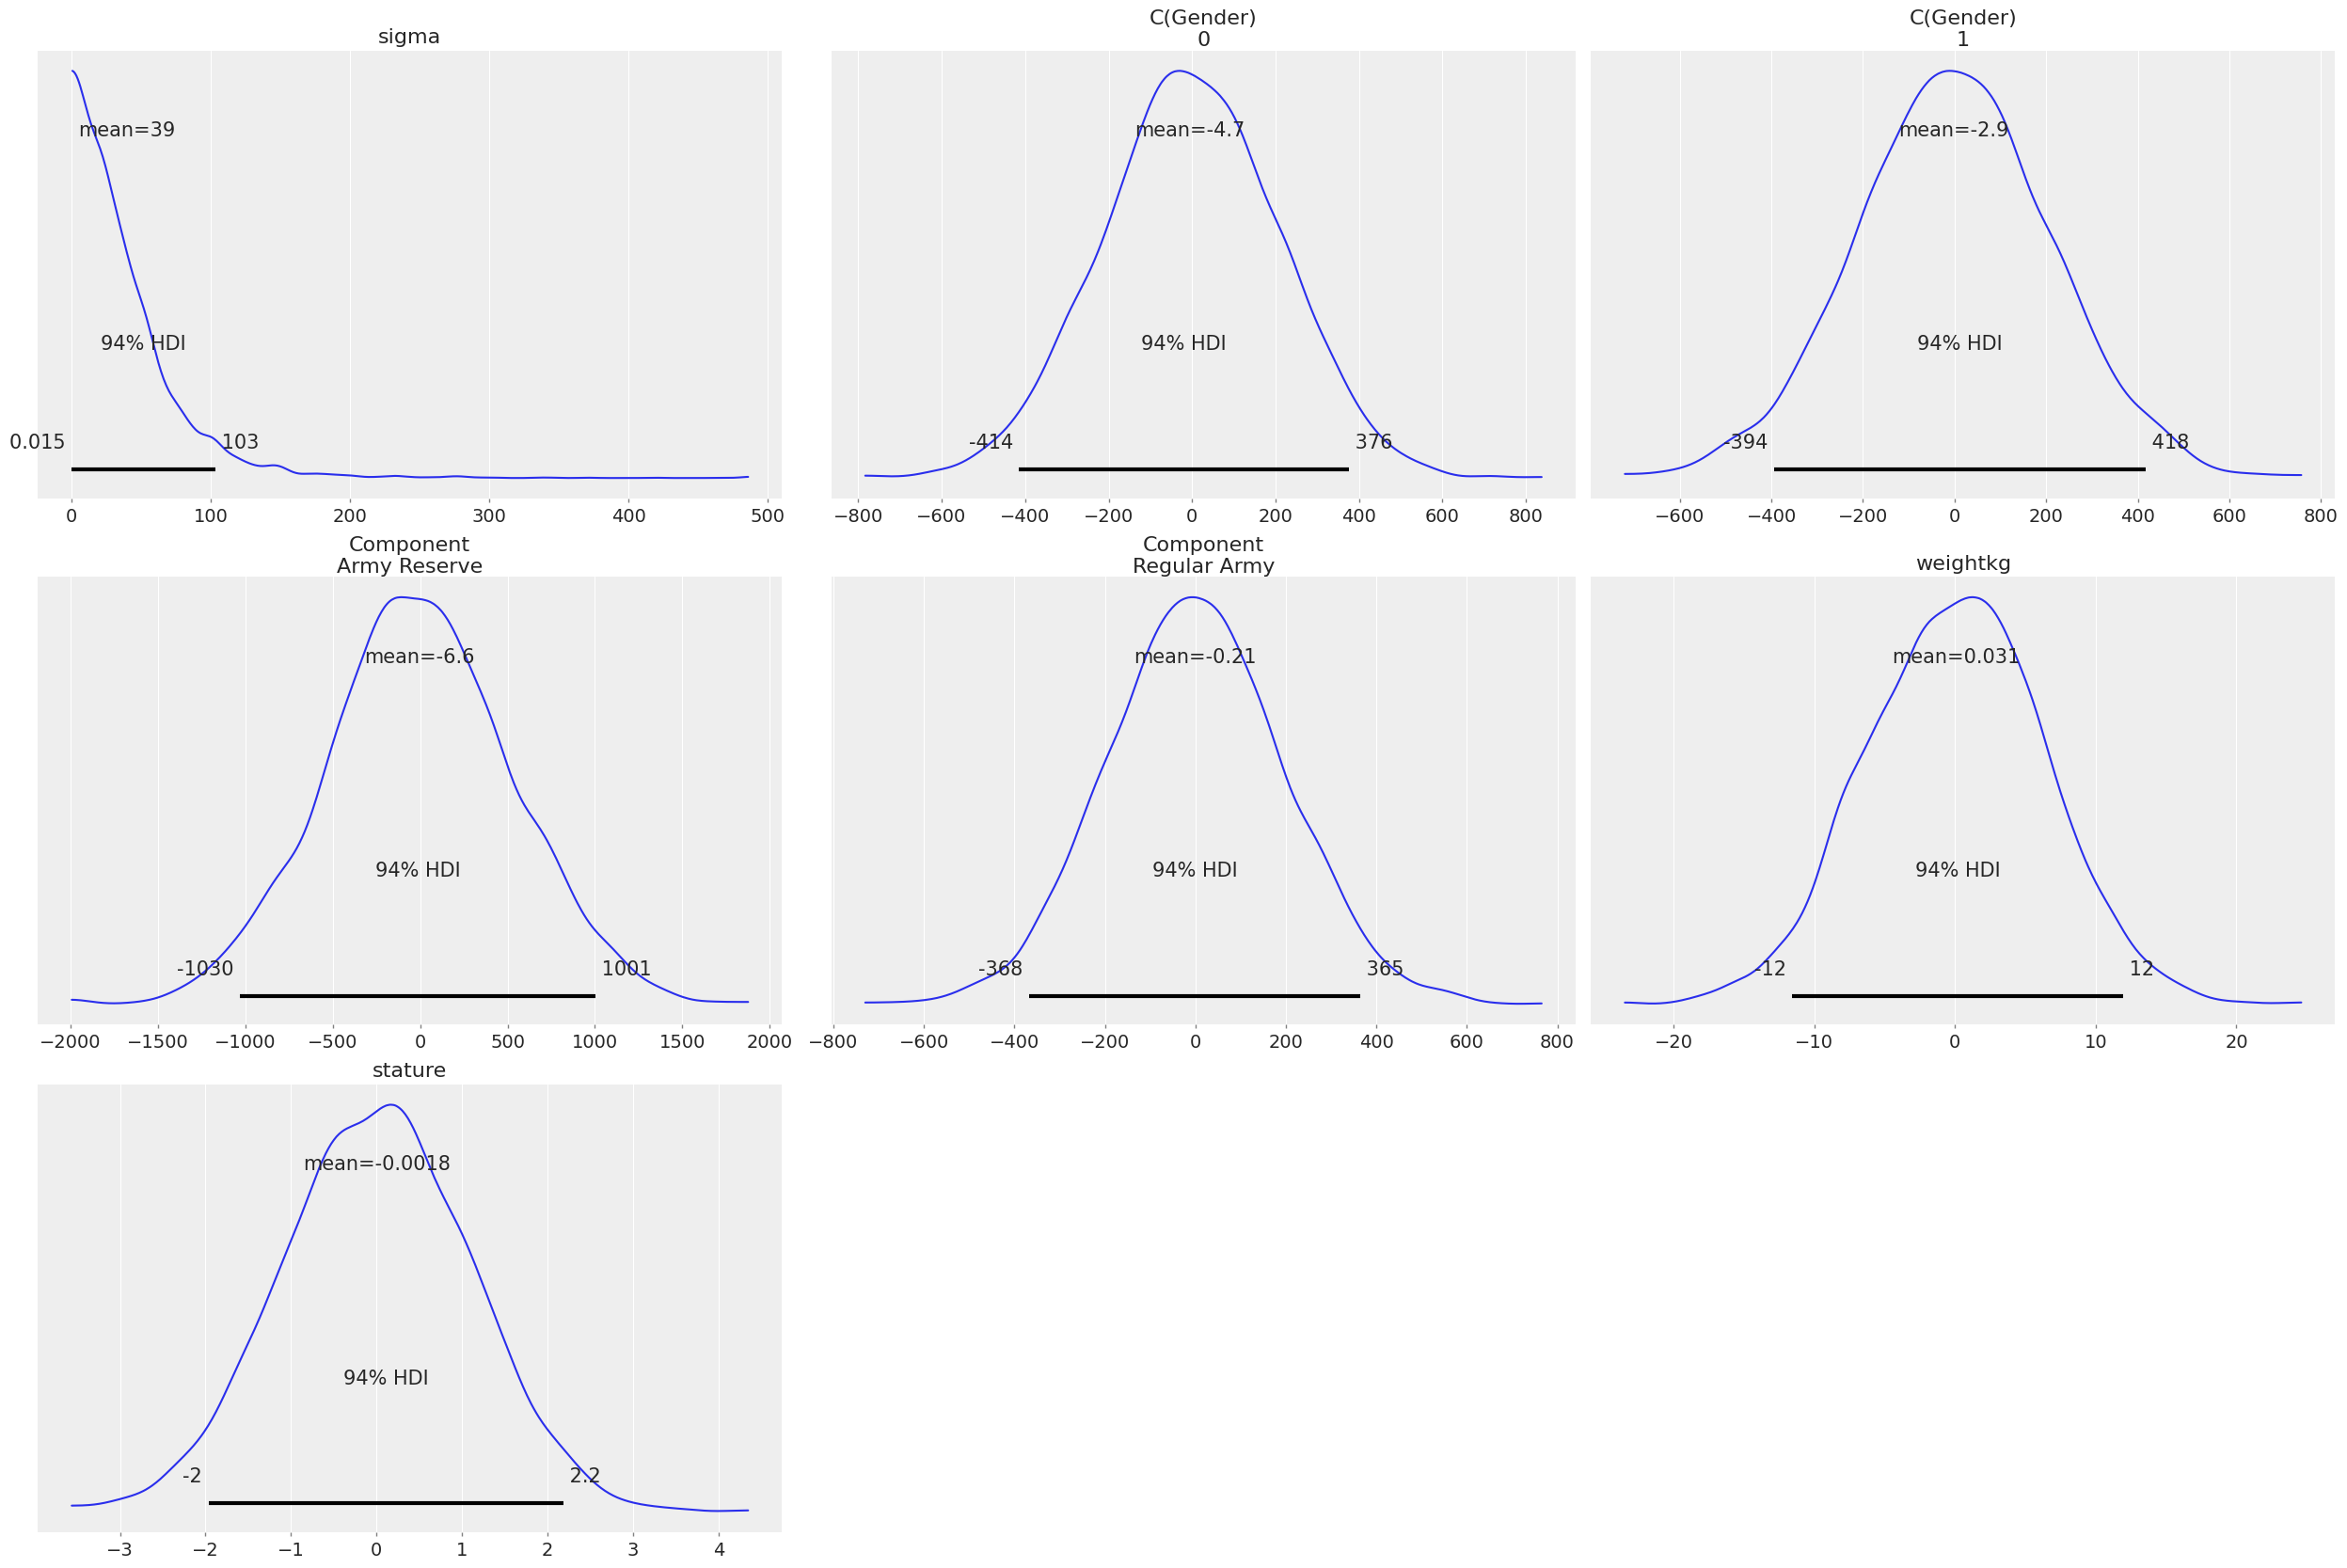

In [19]:
plot_hdi_priors(model)

Plot the HDI of the posteriors.

In [20]:
def plot_hdi_posteriors(fitted, variables:list):
    az.plot_posterior(fitted, var_names=variables)

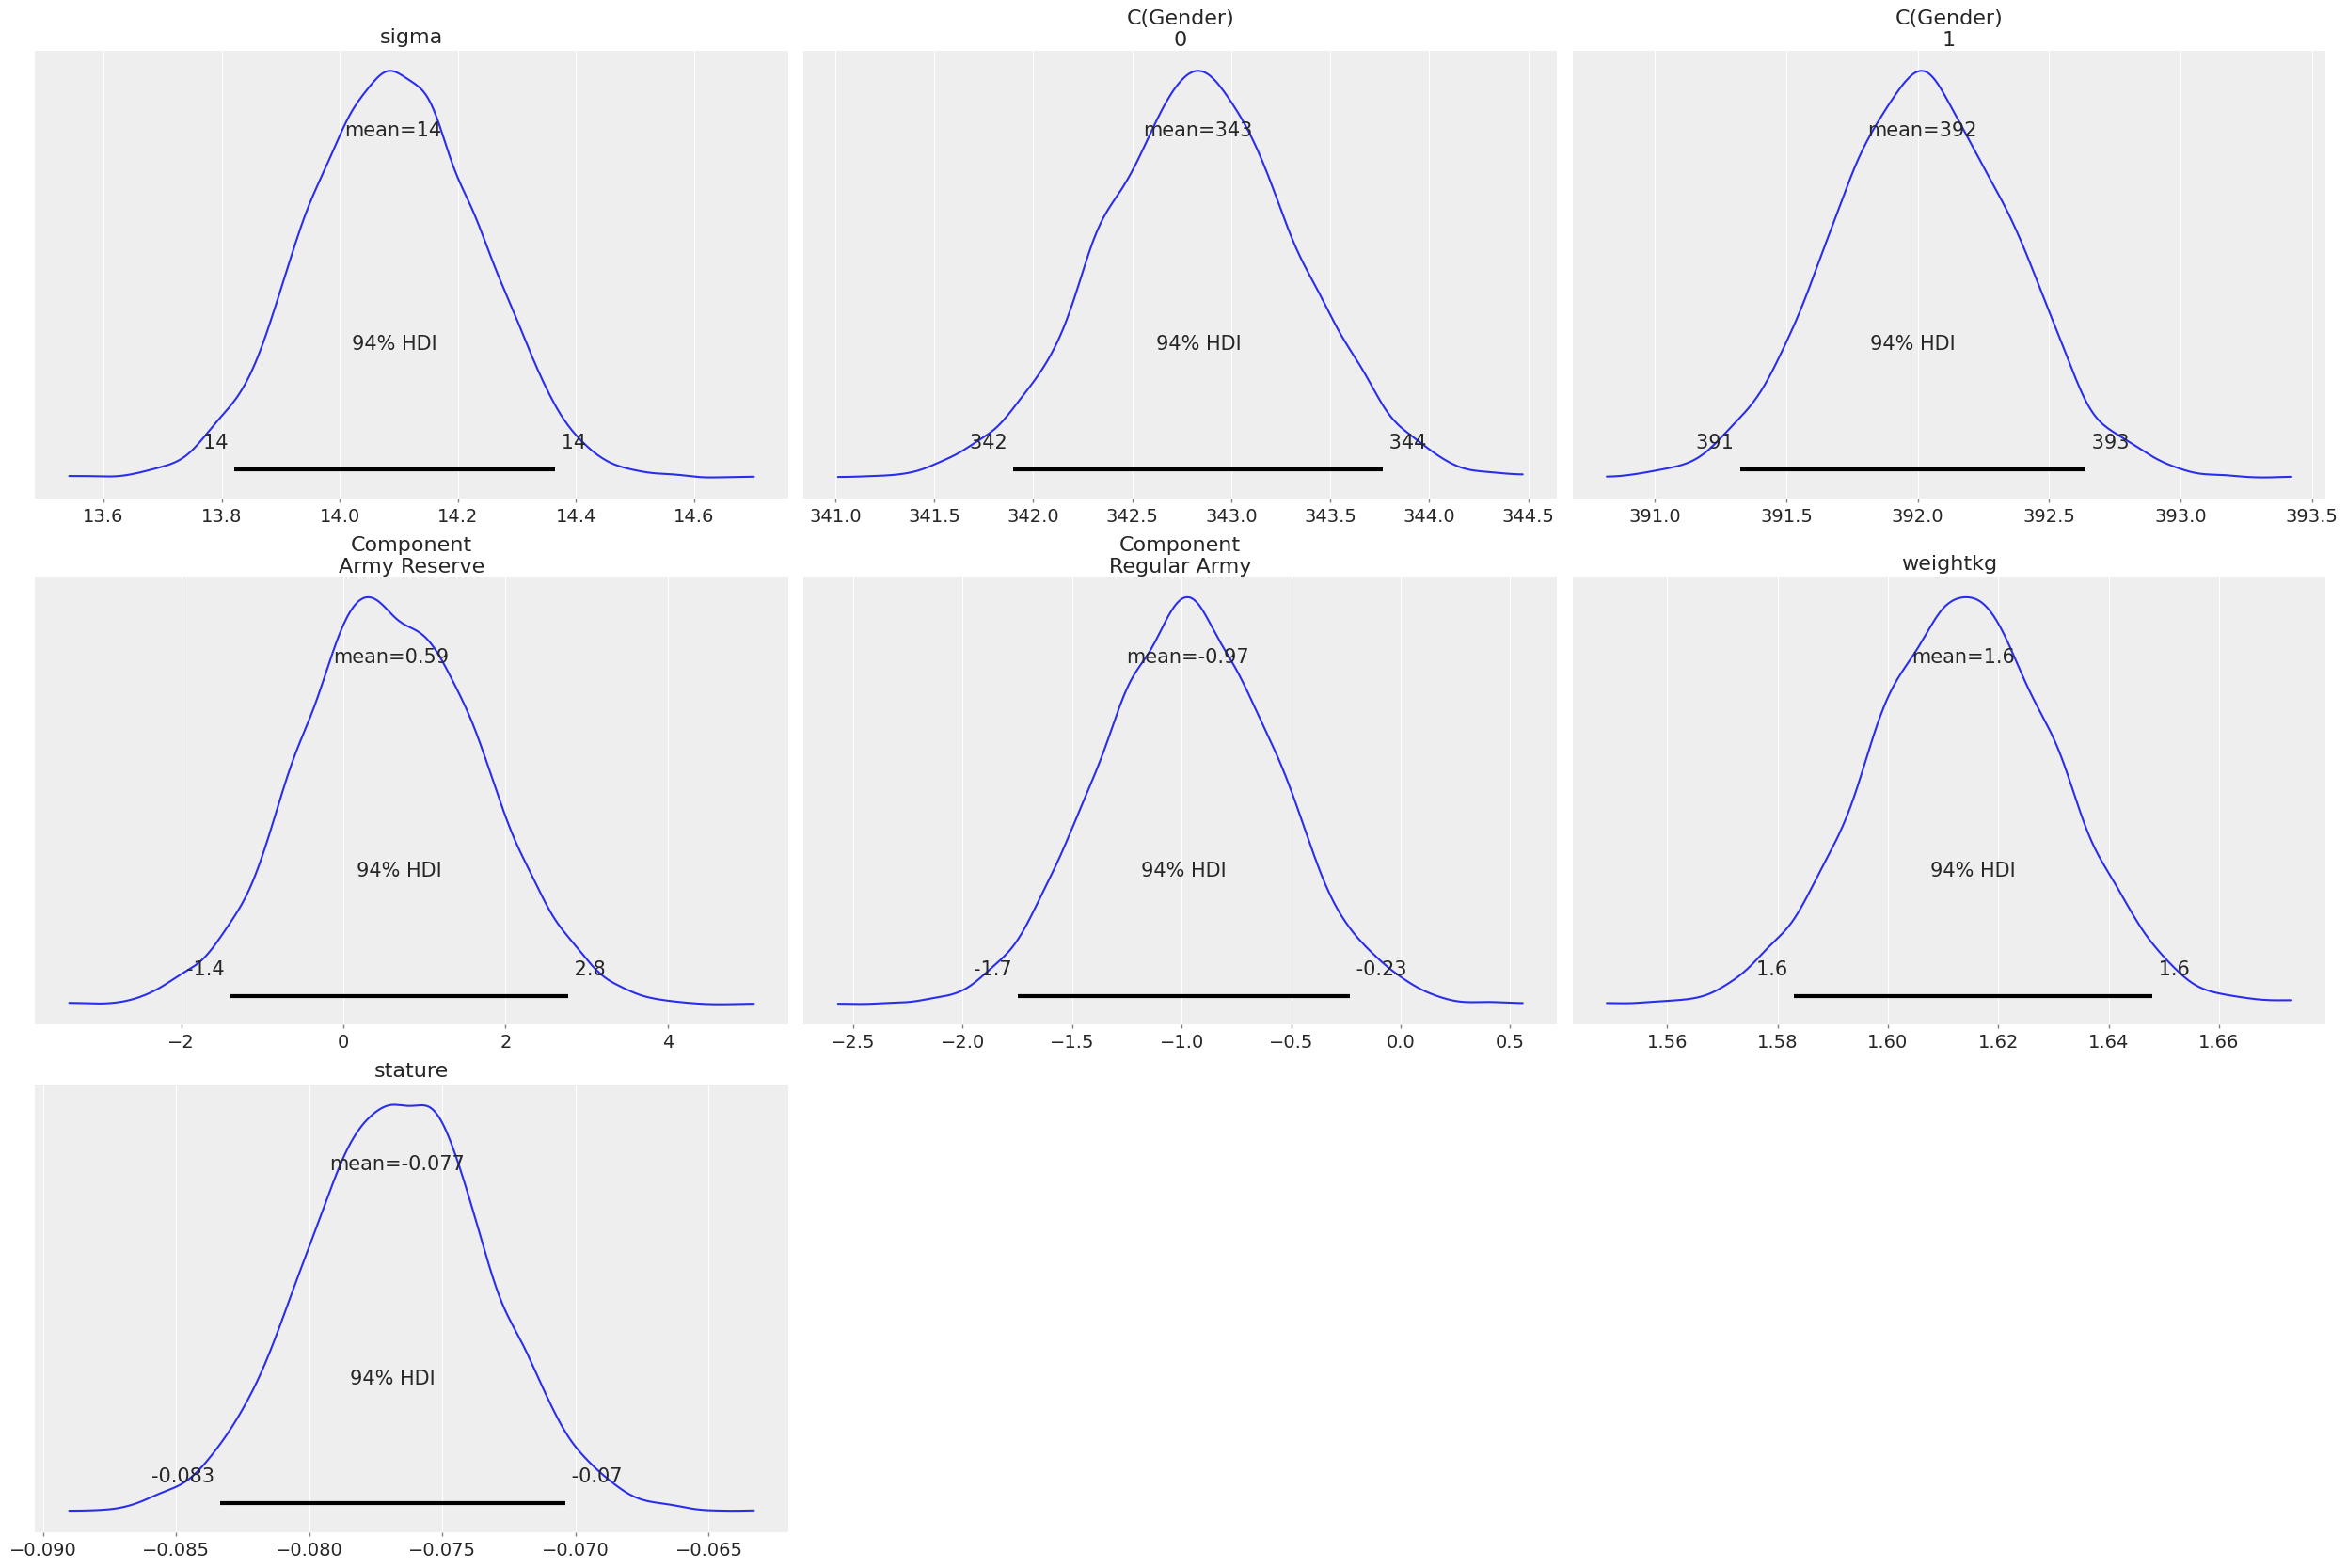

In [21]:
plot_hdi_posteriors(fitted, variables=  ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

Plot the trace plot, with density plot and trace lines.

In [22]:
def plot_trace(fitted, variables:list):
    az.plot_trace(fitted, compact=False, var_names=variables)

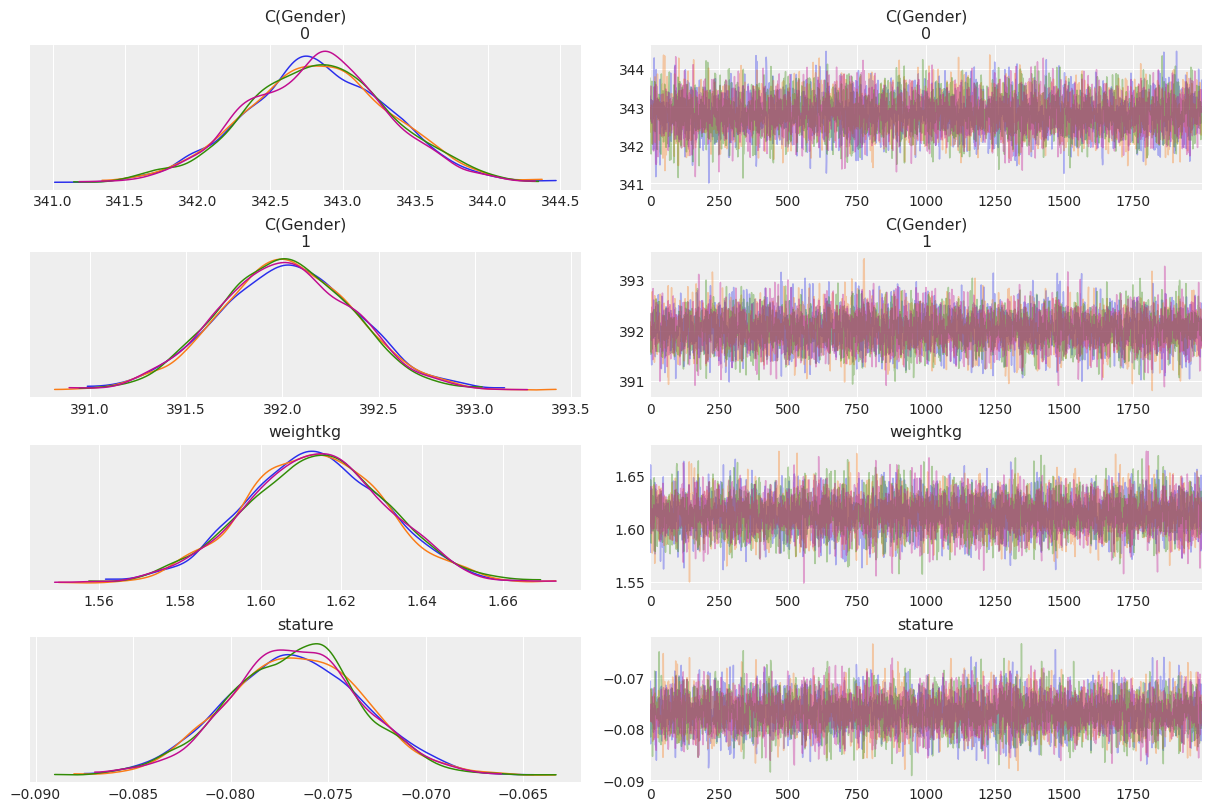

In [23]:
plot_trace(fitted, variables= ["C(Gender)", "weightkg", "stature"])